<a href="https://colab.research.google.com/github/ElviraGD-lab/pajares-mountain-corridor-baseline/blob/main/notebooks/05_cloud_masking_mountains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
else:
    environment = 'local'

print(f'Environment: {environment}')

Environment: colab


In [ ]:
%%capture
if environment == 'colab':
    !pip install pystac-client odc-stac rioxarray dask['distributed'] \
        jupyter-server-proxy odc-algo

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pystac_client
import rioxarray as rxr
import xarray as xr
from matplotlib.colors import ListedColormap
from odc.stac import configure_s3_access, load

In [ ]:
from dask.distributed import Client
client = Client()
client

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40555
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40387'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40059'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:33661 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:33661
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:59134
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44521 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44521
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:59144
INFO:distributed.scheduler:Receive client connection: Client-fb6d82c3-af9b-11f1-9894-0242ac1c000c
INFO:distributed.core:Starting establish

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40555,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33661,Total threads: 1
Dashboard: http://127.0.0.1:46579/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:40387,


In [ ]:
latitude = 43.0000
longitude = -5.7600
year = 2023

In [ ]:
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

In [ ]:
search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={
        'eo:cloud_cover': {'lt': 50},
        's2:nodata_pixel_percentage': {'lt': 10}},
    sortby=[
        {'field': 'properties.eo:cloud_cover',
         'direction': 'desc'}
        ]
)
items = search.item_collection()

most_cloudy = items[0]

In [ ]:
ds = load(
    [most_cloudy],
    bands=['red', 'green', 'blue', 'scl'],
    resolution=100,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},
    groupby='solar_day',
    preserve_original_order=True
)

In [ ]:
scene = ds.squeeze()
scene = scene.where(scene != 0)

In [ ]:
scale = 0.0001
offset = -0.1

data_bands = [band for band in scene.data_vars if band != 'scl']

for band in data_bands:
    scene[band] = scene[band] * scale + offset

scene

<xarray.Dataset> Size: 22MB
Dimensions:      (y: 1175, x: 1174)
Coordinates:
  * y            (y) float64 9kB 4.803e+06 4.803e+06 ... 4.686e+06 4.686e+06
  * x            (x) float64 9kB 2.056e+05 2.058e+05 ... 3.228e+05 3.23e+05
    spatial_ref  int32 4B 32630
    time         datetime64[ns] 8B 2023-12-30T11:29:21.427000
Data variables:
    red          (y, x) float32 6MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    green        (y, x) float32 6MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    blue         (y, x) float32 6MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    scl          (y, x) float32 6MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>

In [ ]:
data_bands = [band for band in scene.data_vars if band != 'scl']

In [ ]:
%%time
scene = scene.compute()

CPU times: user 433 ms, sys: 81.8 ms, total: 515 ms
Wall time: 5.71 s


In [ ]:
scene_da = scene.to_array('band')

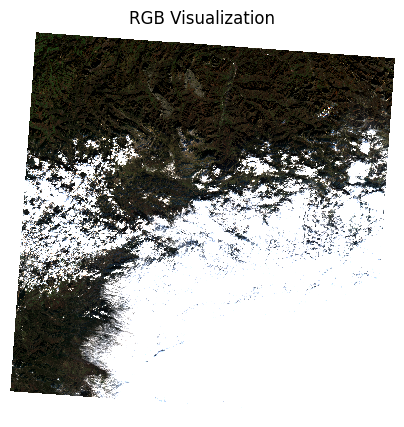

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5, 5)
scene_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    vmin=0, vmax=0.3)
ax.set_title('RGB Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

In [ ]:
# What did the ESA algorithm decide this scene consists of?
scl_values = scene['scl'].values
scl_values = scl_values[~np.isnan(scl_values)]

values, counts = np.unique(scl_values, return_counts=True)

labels = {
    0: 'no data',            1: 'saturated / defective',
    2: 'dark area',          3: 'cloud shadow',
    4: 'vegetation',         5: 'not vegetated',
    6: 'water',              7: 'unclassified',
    8: 'cloud medium prob',  9: 'cloud high prob',
    10: 'thin cirrus',       11: 'snow / ice',
}

total = counts.sum()
for v, c in zip(values, counts):
    print(f'{int(v):2d}  {labels.get(int(v), "?"):22s} {c:9,}  {c / total * 100:5.1f}%')

 2  dark area                206,006   17.1%
 3  cloud shadow              42,462    3.5%
 4  vegetation               266,896   22.1%
 5  not vegetated             98,055    8.1%
 6  water                      1,746    0.1%
 7  unclassified               9,558    0.8%
 8  cloud medium prob         88,546    7.3%
 9  cloud high prob          480,547   39.9%
10  thin cirrus               11,231    0.9%
11  snow / ice                   289    0.0%


In [ ]:
mask = scene['scl'].isin([3, 8, 9, 10])

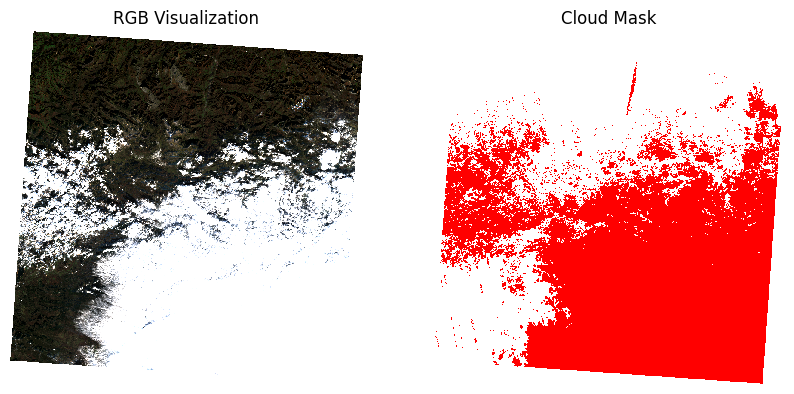

In [ ]:
fig, (ax0, ax1) = plt.subplots(1, 2)
fig.set_size_inches(10, 5)

scene_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax0,
    vmin=0, vmax=0.3)
ax0.set_title('RGB Visualization')

# RGBA: transparent, red
mask_colormap = ListedColormap(['#00000000', '#FF0000FF'])
mask.plot.imshow(
    ax=ax1,
    cmap=mask_colormap,
    add_colorbar=False)
ax1.set_title('Cloud Mask')

for ax in (ax0, ax1):
    ax.set_axis_off()
    ax.set_aspect('equal')

plt.show()

In [ ]:
scene_masked = scene[data_bands].where(~mask)
scene_masked

<xarray.Dataset> Size: 17MB
Dimensions:      (y: 1175, x: 1174)
Coordinates:
  * y            (y) float64 9kB 4.803e+06 4.803e+06 ... 4.686e+06 4.686e+06
  * x            (x) float64 9kB 2.056e+05 2.058e+05 ... 3.228e+05 3.23e+05
    spatial_ref  int32 4B 32630
    time         datetime64[ns] 8B 2023-12-30T11:29:21.427000
Data variables:
    red          (y, x) float32 6MB nan nan nan nan nan ... nan nan nan nan nan
    green        (y, x) float32 6MB nan nan nan nan nan ... nan nan nan nan nan
    blue         (y, x) float32 6MB nan nan nan nan nan ... nan nan nan nan nan

In [ ]:
valid = int(scene_masked['red'].notnull().sum())
total = int(scene['scl'].notnull().sum())
print(f'Valid after masking: {valid:,} of {total:,}  ({valid / total * 100:.1f}%)')

Valid after masking: 582,550 of 1,205,336  (48.3%)


In [ ]:
from odc.algo import mask_cleanup

BUFFER_M = 100
radius_px = max(1, round(BUFFER_M / resolution))
print(f'Buffer {BUFFER_M} m at {resolution} m/px -> {radius_px} px')

# Three variants, three names. Nothing overwrites anything, so the plot
# below always shows what its code says it shows.
mask_opened = mask_cleanup(mask, [('opening', 2)])
mask_closed = mask_cleanup(mask, [('closing', 3)])
mask_buffered = mask_cleanup(mask, [('closing', 2), ('dilation', radius_px)])

for name, m in [('original', mask), ('opening', mask_opened),
                ('closing', mask_closed), ('closing+dilation', mask_buffered)]:
    print(f'{name:20s} {int(m.sum()):9,}')

Buffer 100 m at 100 m/px -> 1 px
original               622,786
opening                591,059
closing                678,549
closing+dilation       692,034


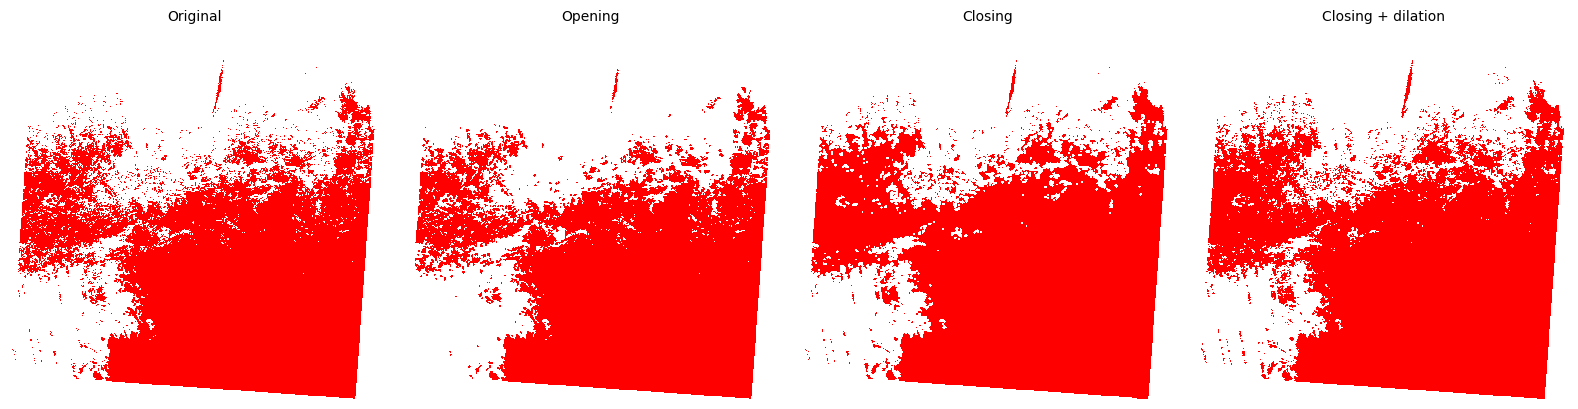

In [ ]:
fig, axes = plt.subplots(1, 4)
fig.set_size_inches(16, 4)

mask_colormap = ListedColormap(['#00000000', '#FF0000FF'])

variants = [('Original', mask), ('Opening', mask_opened),
            ('Closing', mask_closed), ('Closing + dilation', mask_buffered)]

for ax, (title, m) in zip(axes, variants):
    m.plot.imshow(ax=ax, cmap=mask_colormap, add_colorbar=False)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()